In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json 
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter

import re 

## Plot results from Popham-style conditions using SWC stimuli

### Import human data

In [2]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_popham_swc_word_recognition/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)


96

## Process Human Results

In [3]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

import re
### Get condition map
with open('swc_popham_exmpt_2024_cond_manifest.pkl', 'rb') as f:
    stim_cond_map = pickle.load(f)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    target_harm, dist_harm = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            target_harm = stim_cond_map[cond_str]['target_harmonicity']
            dist_harm = stim_cond_map[cond_str]['distractor_harmonicity']
            if dist_harm is None:
                dist_harm = 'No Distractor'
            target_harm = target_harm.title()
            dist_harm = dist_harm.title()
        elif 'catch' in stim_str:
            target_harm = 'catch_trial'
            dist_harm = 'No Distractor'
    return target_harm, dist_harm

# add as columns 
results_df['target_harmonicity'], results_df['distractor_harmonicity'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]


# screen based on completion 
total_trials = 192 
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').target_harmonicity.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# # Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')


Unterminated string starting at: line 1 column 72251 (char 72250)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_55b899c5fdf99b7323bc60e0.json
Unterminated string starting at: line 1 column 96293 (char 96292)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_5e83b9e3e3a9da1163fdd0dc.json
Unterminated string starting at: line 1 column 277004 (char 277003)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_59b5a275c05bb50001eb3c4b.json
Unterminated string starting at: line 1 column 228622 (char 228621)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_5fc00a11268eb941e7d8b066.json
Unterminated string starting at: line 1 column 289094 (char 289093)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_5f6b8c1f5622370b0c94d597.json
Expecting ',' delimiter: line 1 column 

In [4]:
# trial_results.groupby('id_subject').target_harmonicity.count()

In [5]:
catch_trial_particiapnt_performance = trial_results[trial_results.target_harmonicity == 'catch_trial'].groupby('id_subject').accuracy.mean()
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]

analysis_df = good_results[(~good_results.target_harmonicity.isnull()) & (~good_results.response.isna())]
analysis_df = analysis_df[analysis_df.target_harmonicity != 'catch_trial']

# analysis_df.groupby('id_subject').target_harmonicity.count()

N total participants  45
N good participants  36



## Add re-scored performance based on entries included in excerpt transcripts  

In [6]:
meta_df = pd.read_pickle('/om/user/imgriff/datasets/human_swc_popham_exmpt_2024/source_stim_meta_manifest.pdpkl')

analysis_df = pd.merge(analysis_df,
                        meta_df[['word', 'word_int', 'distractor_word', 'target_transcripts', 'distractor_transcripts', 'gender_cond']],
                        left_on=['correct_response'], right_on=['word'], how='left')     
                        
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')
# add adjusted accuracy and confusions 
target_words = analysis_df.response.values
target_transcripts = analysis_df.target_transcripts.values
distractor_transcripts = analysis_df.distractor_transcripts.values
distractor_words = analysis_df.distractor_word.values


adjusted_acc = np.array([int(target_word in target_transcript)
                            if not isinstance(target_transcript, float) else np.nan
                             for target_word, target_transcript in zip(target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int((target_word in distractor_transcript) or (target_word == distractor_word))
                            if not isinstance(distractor_transcript, float) else np.nan
                             for target_word, distractor_word, distractor_transcript in zip(target_words, distractor_words, distractor_transcripts)
                              ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

In [7]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(['id_subject', "target_harmonicity", 'distractor_harmonicity'])
                     .agg({'correct':['mean', 'sem'],
                            'confusions':['mean', 'sem'],
                            'adjusted_accuracy':['mean', 'sem'],
                            'adjusted_confusions':['mean', 'sem', 'count']})
                     .reset_index())

# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


## Set paths and load model results 

In [8]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


In [21]:
# parent_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/popham_mono_eval/')
parent_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/popham_swc_eval/')

# model_name = 'word_task_standard_v08'
# model_name = 'word_task_half_co_loc_v07'

meta_df = pd.read_pickle('/om/user/imgriff/datasets/human_swc_popham_exmpt_2024/source_stim_meta_manifest.pdpkl')

results_dirs = list(parent_path.rglob(f"*/*.csv"))
print(len(results_dirs))

dfs = []

for result_csv in results_dirs:
    df = pd.read_csv(result_csv)
    df['target_harmonicity'] = result_csv.stem.split('_target')[0].split('_')[-1].title()
    df['model'] = result_csv.parent.stem
    dist_harm = result_csv.stem.split('_distractor')[0].split('_')[-1].title()
    if dist_harm == 'No':
        dist_harm = 'No Distractor'
    df['distractor_harmonicity'] = dist_harm
    df['target_word'] = df['true_word_int'].replace(cv_class_2_word)
    df['pred_word'] = df['pred_word_int'].replace(cv_class_2_word)
    df = pd.merge(df,
                 meta_df[['word', 'word_int', 'distractor_word', 'target_transcripts', 'distractor_transcripts', 'gender_cond']],
                 left_on=['target_word', 'true_word_int'], right_on=['word', 'word_int'], how='left')     
    dfs.append(df)

model_results = pd.concat(dfs, axis=0, ignore_index=True)
model_results['confusions'] = (model_results.pred_word == model_results.distractor_word).astype('int')
# add adjusted accuracy and confusions 
target_words = model_results.pred_word.values
target_transcripts = model_results.target_transcripts.values
distractor_transcripts = model_results.distractor_transcripts.values


adjusted_acc = np.array([int(target_word in target_transcript)
                            if not isinstance(target_transcript, float) else np.nan
                            for target_word, target_transcript in zip(target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(target_word in distractor_transcript)
                            if not isinstance(distractor_transcript, float) else np.nan
                            for target_word, distractor_transcript in zip(target_words, distractor_transcripts)
                            ])

model_results['adjusted_accuracy'] = adjusted_acc
model_results['adjusted_confusions'] = adjusted_confs

36


### Conform data to plot 

In [22]:
model_results.distractor_harmonicity.unique()

array(['Harmonic', 'Inharmonic', 'No Distractor', 'Whispered'],
      dtype=object)

In [32]:
melted_model_results = pd.melt(model_results, id_vars=['target_harmonicity', 'model', 'distractor_harmonicity'],
        value_vars=['accuracy', 'confusions'],
        value_name = 'hits',
        var_name = 'attended_stream')

group_name_df = {'word_task_half_co_loc_v07': "Feature-based\nattention model", "word_task_v08_control_no_attn": "Baseline CNN"}

# melted_model_results['attended_stream'][melted_model_results['attended_stream'] == 'accuracy'] = "Cued stream"
# melted_model_results['attended_stream'][melted_model_results['attended_stream'] == 'confusions']= "Uncued stream"
melted_model_results.loc[melted_model_results['attended_stream'] == 'accuracy', 'attended_stream'] = "Target"
melted_model_results.loc[melted_model_results['attended_stream'] == 'confusions', 'attended_stream'] =  "Distractor"


IDX_no_dist_confs = melted_model_results.loc[(melted_model_results['distractor_harmonicity'] == 'No Distractor') & (melted_model_results.attended_stream == 'Distractor') ].index.values
melted_model_results = melted_model_results[~melted_model_results.index.isin(IDX_no_dist_confs)]
melted_model_results.loc[melted_model_results['distractor_harmonicity'] == 'No Distractor', 'attended_stream'] = "Single sentence"
melted_model_results['group'] = melted_model_results['model'].replace(group_name_df)

In [33]:

melted_model_results

,target_harmonicity,model,distractor_harmonicity,attended_stream,hits,group
0,Harmonic,word_task_half_co_loc_v07,Harmonic,Target,1,Feature-based\nattention model
1,Harmonic,word_task_half_co_loc_v07,Harmonic,Target,0,Feature-based\nattention model
2,Harmonic,word_task_half_co_loc_v07,Harmonic,Target,0,Feature-based\nattention model
3,Harmonic,word_task_half_co_loc_v07,Harmonic,Target,0,Feature-based\nattention model
4,Harmonic,word_task_half_co_loc_v07,Harmonic,Target,1,Feature-based\nattention model
...,...,...,...,...,...,...
25915,Whispered,word_task_v08_control_no_attn,Whispered,Distractor,0,Baseline CNN
25916,Whispered,word_task_v08_control_no_attn,Whispered,Distractor,0,Baseline CNN
25917,Whispered,word_task_v08_control_no_attn,Whispered,Distractor,0,Baseline CNN
25918,Whispered,word_task_v08_control_no_attn,Whispered,Distractor,0,Baseline CNN


In [34]:
part_summary_df.target_harmonicity.unique()

array(['Harmonic', 'Inharmonic', 'Whispered'], dtype=object)

In [35]:
melted_participant_results = pd.melt(part_summary_df, id_vars=['id_subject', 'target_harmonicity', 'distractor_harmonicity'],
        value_vars=['adjusted_accuracy_mean', 'adjusted_confusions_mean'],
        value_name = 'hits',
        var_name = 'attended_stream')

melted_participant_results.loc[melted_participant_results['attended_stream'] == 'adjusted_accuracy_mean', 'attended_stream'] = "Target"
melted_participant_results.loc[melted_participant_results['attended_stream'] == 'adjusted_confusions_mean', 'attended_stream'] =  "Distractor"

IDX_no_dist_confs = melted_participant_results.loc[(melted_participant_results['distractor_harmonicity'] == 'No Distractor') & (melted_participant_results.attended_stream == 'Distractor') ].index.values
melted_participant_results = melted_participant_results[~melted_participant_results.index.isin(IDX_no_dist_confs)]
melted_participant_results.loc[melted_participant_results['distractor_harmonicity'] == 'No Distractor', 'attended_stream'] = "Single sentence"
melted_participant_results['group'] = f'Human (N = {melted_participant_results.id_subject.nunique()})'

#### merge human and model results

In [36]:
melted_results = pd.concat([melted_participant_results, melted_model_results], axis=0, ignore_index=True)
melted_results

,id_subject,target_harmonicity,distractor_harmonicity,attended_stream,hits,group,model
0,5b715c07e1727c0001e5e9cb,Harmonic,Harmonic,Target,0.666667,Human (N = 36),NaN
1,5b715c07e1727c0001e5e9cb,Harmonic,Inharmonic,Target,0.600000,Human (N = 36),NaN
2,5b715c07e1727c0001e5e9cb,Harmonic,No Distractor,Single sentence,0.800000,Human (N = 36),NaN
3,5b715c07e1727c0001e5e9cb,Harmonic,Whispered,Target,0.800000,Human (N = 36),NaN
4,5b715c07e1727c0001e5e9cb,Inharmonic,Harmonic,Target,0.733333,Human (N = 36),NaN
...,...,...,...,...,...,...,...
23431,NaN,Whispered,Whispered,Distractor,0.000000,Baseline CNN,word_task_v08_control_no_attn
23432,NaN,Whispered,Whispered,Distractor,0.000000,Baseline CNN,word_task_v08_control_no_attn
23433,NaN,Whispered,Whispered,Distractor,0.000000,Baseline CNN,word_task_v08_control_no_attn
23434,NaN,Whispered,Whispered,Distractor,0.000000,Baseline CNN,word_task_v08_control_no_attn


### Original-style figure 

In [30]:
to_plot.distractor_harmonicity.unique()

['No Distractor', 'Harmonic', 'Inharmonic', 'Whispered']
Categories (4, object): ['No Distractor', 'Harmonic', 'Inharmonic', 'Whispered']

In [55]:
outfig_dest = Path('CCN_2024/figures')
outfig_dest.mkdir(parents=True, exist_ok=True)

/tmp/ipykernel_31839/1172603760.py:28: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  g = sns.relplot(kind='line',


Text(0.5, 1.1, 'Inharmonic and Whispered Speech')

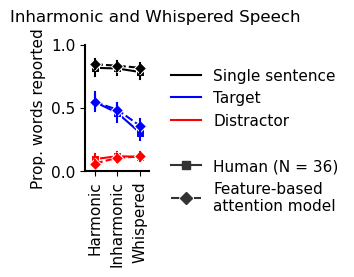

In [92]:
order = ['Harmonic', 'Inharmonic', 'Whispered']

hues = ['k', 'b', 'r']
hue_order = ['Single sentence', 'Target', 'Distractor']
fontsize=11

to_plot = melted_results[(melted_results.target_harmonicity == melted_results.distractor_harmonicity) | (melted_results.distractor_harmonicity == 'No Distractor')]
no_dist_IXS = to_plot[to_plot.distractor_harmonicity == 'No Distractor'].index.values
to_plot.loc[no_dist_IXS, 'distractor_harmonicity'] = to_plot.loc[no_dist_IXS, 'target_harmonicity'] 
to_plot =to_plot[to_plot.distractor_harmonicity != 'No Distractor']

# g = sns.catplot(kind='point',
#     data=to_plot,
#     # col='target_harmonicity',
#      y='hits',
#     hue = 'attended_stream', hue_order=hue_order,
#     palette=hues,
#     order = order,
#     # markers='.',
#     x='distractor_harmonicity',
# #     hue='distractor_harmonicity', hue_order=hue_order, palette=distractor_palette,
# #     col='subject',
#     seed=1, 
#     errorbar=('ci', 95),
#     height=6, aspect=.75
# )

g = sns.relplot(kind='line',
    data=to_plot,
    # col='target_harmonicity',
    # col_order=[ 'Harmonic', 'Inharmonic', 'Whispered'],
    y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    # order = order,
    x='distractor_harmonicity',
    style='group', style_order=[f'Human (N = {melted_participant_results.id_subject.nunique()})', "Feature-based\nattention model"],
    markers=['s', 'D', 'o'],
    sort=False,
#     hue='distractor_harmonicity', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    err_style='bars',
    seed=1, 
    errorbar=('se', 2),
    height=2, aspect=2
    
)

# add space on x axis between y axis and first points
g.ax.margins(x=0.2)

g.set_axis_labels("", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=90, size=fontsize)
# rotate x tick labels but keep them right aligned





g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right",  bbox_to_anchor=(0.85, .5), #handlelength=0,
                frameon=False, title_size=fontsize, fontsize=fontsize)
g.legend.texts[0].set_text('')
g.legend.texts[4].set_text('')

ratio = 2
y_ticks = np.linspace(0,1,3).round(1)
for ax in g.axes.flat:
    ax.set_yticks(ticks=y_ticks) # set new labels
    ax.set_yticklabels(labels= y_ticks, fontsize=fontsize)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)

plt.ylim(0,1)
# g.fig.subplots_adjust(top=0.5) # adjust the Figure in rp
g.fig.suptitle('Inharmonic and Whispered Speech', y=1.1)
# g.fig.tight_layout()
# plt.savefig(outfig_dest/'popham_conds.pdf', transparent=True, bbox_inches='tight')

### Make scatter plots putting model vs human together. One for words correct one for confusions

In [21]:
part_summary_df.columns

Index(['id_subject', 'target_harmonicity', 'distractor_harmonicity',
       'correct_mean', 'correct_sem', 'confusions_mean', 'confusions_sem',
       'adjusted_accuracy_mean', 'adjusted_accuracy_sem',
       'adjusted_confusions_mean', 'adjusted_confusions_sem',
       'adjusted_confusions_count'],
      dtype='object')

In [22]:
part_summary_df['group'] = f'Participants'
model_results['group'] = 'Model'

part_summary = part_summary_df.groupby(['target_harmonicity', 'distractor_harmonicity']).agg({"adjusted_accuracy_mean":['mean', 'sem'], "adjusted_confusions_mean":['mean', 'sem']}).reset_index()

# flatten multiindex 
part_summary.columns = ['_'.join(col).strip() for col in part_summary.columns.values]
# remove trailing underscore
part_summary.columns = [col[:-1] if col.endswith('_') else col for col in part_summary.columns.values]

part_summary.rename(columns={"adjusted_accuracy_mean_mean":"participant_accuracy",
                                "adjusted_confusions_mean_mean": "participant_confusions",
                                "adjusted_accuracy_mean_sem": "participant_acc_sem",
                                "adjusted_confusions_mean_sem": "participant_conf_sem",
                                 }, inplace=True)
part_summary

,target_harmonicity,distractor_harmonicity,participant_accuracy,participant_acc_sem,participant_confusions,participant_conf_sem
0,Harmonic,Harmonic,0.548148,0.037947,0.096296,0.018864
1,Harmonic,Inharmonic,0.566667,0.039708,0.098148,0.014665
2,Harmonic,No Distractor,0.816667,0.031914,0.003704,0.002581
3,Harmonic,Whispered,0.538889,0.037691,0.098148,0.019425
4,Inharmonic,Harmonic,0.498148,0.046347,0.100000,0.023682
5,Inharmonic,Inharmonic,0.461111,0.037598,0.118519,0.017030
6,Inharmonic,No Distractor,0.811111,0.026627,0.001852,0.001852
7,Inharmonic,Whispered,0.474074,0.039644,0.111111,0.016798
8,Whispered,Harmonic,0.448148,0.041710,0.096296,0.019777
9,Whispered,Inharmonic,0.450000,0.035474,0.079630,0.015446


In [23]:
model_summary = model_results.groupby(['target_harmonicity', 'distractor_harmonicity']).agg({"adjusted_accuracy":['mean', 'sem'], "adjusted_confusions":['mean', 'sem']}).reset_index()

# flatten multiindex 
model_summary.columns = ['_'.join(col).strip() for col in model_summary.columns.values]
# remove trailing underscore
model_summary.columns = [col[:-1] if col.endswith('_') else col for col in model_summary.columns.values]

model_summary.rename(columns={"adjusted_accuracy_mean":"model_accuracy",
                                "adjusted_confusions_mean": "model_confusions",
                                "adjusted_accuracy_sem": "model_acc_sem",
                                "adjusted_confusions_sem": "model_conf_sem",
                                 }, inplace=True)
model_summary

,target_harmonicity,distractor_harmonicity,model_accuracy,model_acc_sem,model_confusions,model_conf_sem
0,Harmonic,Harmonic,0.538889,0.026309,0.058333,0.012370
1,Harmonic,Inharmonic,0.552778,0.026242,0.069444,0.013417
2,Harmonic,No Distractor,0.825000,0.020054,0.002778,0.002778
3,Harmonic,Whispered,0.508333,0.026385,0.050000,0.011503
4,Inharmonic,Harmonic,0.577778,0.026068,0.038889,0.010204
5,Inharmonic,Inharmonic,0.477778,0.026363,0.097222,0.015636
6,Inharmonic,No Distractor,0.825000,0.020054,0.002778,0.002778
7,Inharmonic,Whispered,0.452778,0.026271,0.066667,0.013165
8,Whispered,Harmonic,0.572222,0.026112,0.019444,0.007288
9,Whispered,Inharmonic,0.516667,0.026374,0.050000,0.011503


In [29]:
for_scatter = model_summary.merge(part_summary)


In [25]:
from scipy import stats

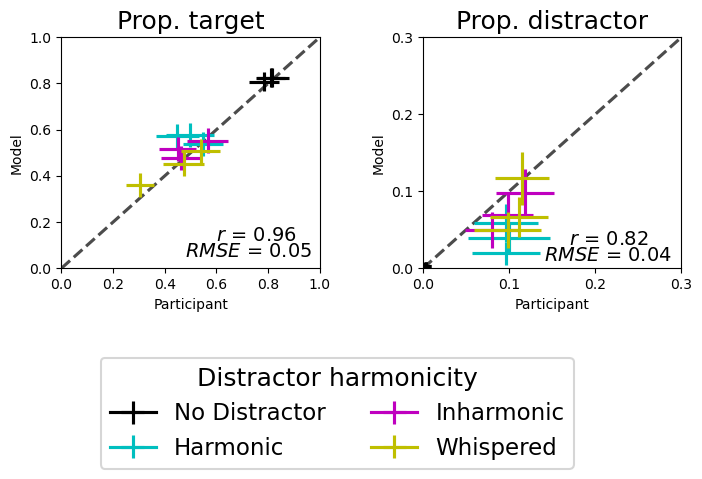

In [26]:
# plot human performance against model performance
fig, axs =  plt.subplots(1,2, figsize=(8,3))

sns.set_context('talk')
fontsize=18
# make  palette for texture labels
# palette = sns.color_palette("husl", len(harmonicity))
distractor_harms = ["No Distractor", 'Harmonic', 'Inharmonic', 'Whispered']
colors = ['k', 'c', 'm', 'y']
palette_dict = {harm:colors[ix] for ix, harm in enumerate(distractor_harms)}

harmonicity =  ['Harmonic', 'Inharmonic', 'Whispered']
markers = ['1', '+', '.']
marker_dict = {harm:markers[ix] for ix, harm in enumerate(harmonicity)}

x = y = np.linspace(0,1,5)
# plot data with 2 sem error bars
axs[0].plot(x,y, ls='dashed', color='k', alpha=0.7)
axs[1].plot(x,y, ls='dashed', color='k', alpha=0.7)


for_scatter.distractor_harmonicity = pd.CategoricalIndex(for_scatter.distractor_harmonicity, categories=['No Distractor', 'Harmonic', 'Inharmonic', 'Whispered'])
for_scatter.sort_values('distractor_harmonicity', inplace=True)
for_scatter.distractor_harmonicity = for_scatter.distractor_harmonicity.to_list()


for ix, row in for_scatter.iterrows():
    axs[0].errorbar(x=row['participant_accuracy'],
            y=row['model_accuracy'],
            xerr = row['participant_acc_sem']*2,
            yerr=row['model_acc_sem']*2,
            label=f"{row['distractor_harmonicity']}",
            color=palette_dict[row['distractor_harmonicity']],
        #     marker=marker_dict[row['target_harmonicity']]
        )   


    axs[1].errorbar(x=row['participant_confusions'],
            y=row['model_confusions'],
            xerr = row['participant_conf_sem']*2,
            yerr=row['model_conf_sem']*2, 
            label=f"{row['distractor_harmonicity']}",
            color=palette_dict[row['distractor_harmonicity']],
        #     marker=marker_dict[row['target_harmonicity']]
        )

            # marker='o', linestyle=None, ms=3, elinewidth=2.5,)
# accs = sns.scatterplot(data=for_scatter, x='participant_accuracy', y='model_accuracy',
#         hue='distractor_harmonicity', palette=palette_dict, style='target_harmonicity', ax=axs[0])


# confs = sns.scatterplot(data=for_scatter, x='participant_confusions', y='model_confusions',
#         hue='distractor_harmonicity', palette=palette_dict, style='target_harmonicity', ax=axs[1],
#         )

# sns.despine()
# accs.legend().remove()


axs[0].set_xlim(0,1)
axs[0].set_ylim(0,1)

axs[0].set_xticks(np.linspace(0,1,6))
axs[0].set_yticks(np.linspace(0,1,6))

axs[1].set_xlim(0,.3)
axs[1].set_ylim(0,.3)


axs[0].set_title("Prop. target")
axs[0].set_xlabel('Participant')
axs[0].set_ylabel('Model')

axs[1].set_title("Prop. distractor")
axs[1].set_xlabel('Participant')
axs[1].set_ylabel('Model')

# Add error annotations 
# acc errors 
# res = stats.spearmanr(for_scatter["participant_accuracy"].values,  for_scatter['model_accuracy'].values)
# rho = res.statistic
# axs[0].annotate(f"$Rho$ = {rho:.2f}", (0.48, 0.12), fontsize=14)
r_model_human, p = stats.pearsonr(for_scatter["participant_accuracy"].values,  for_scatter['model_accuracy'].values)
axs[0].annotate(f"$r$ = {r_model_human:.2f}", (0.6, 0.12), fontsize=14)

samp_rmse = np.sqrt(np.mean((for_scatter["participant_accuracy"].values - for_scatter['model_accuracy'].values)**2))
axs[0].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.48, 0.05), fontsize=14)
# conf errors
# res = stats.spearmanr(for_scatter["participant_confusions"].values,  for_scatter['model_confusions'].values)
# rho = res.statistic
# axs[1].annotate(f"$Rho$ = {rho:.2f}", (0.14, 0.03), fontsize=14)   # old xy coords ( 0.25, 0.05)
r_model_human, p  = stats.pearsonr(for_scatter["participant_confusions"].values,  for_scatter['model_confusions'].values)
axs[1].annotate(f"$r$ = {r_model_human:.2f}", (0.17, 0.03), fontsize=14)   # old xy coords ( 0.25, 0.05)
samp_rmse = np.sqrt(np.mean((for_scatter["participant_confusions"].values - for_scatter['model_confusions'].values)**2))
axs[1].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.14, 0.01), fontsize=14) # old xy coords ( 0.25, 0.025)




# sns.move_legend(confs, title='', loc="center right", 
#                  bbox_to_anchor=(2.5, .5),
#                 frameon=False, )#title_size=fontsize, fontsize=fontsize)

lines_labels = [ax.get_legend_handles_labels() for ax in [axs[1]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines[::3], labels[::3],
            bbox_transform=fig.transFigure,  ncol=2, title='Distractor harmonicity',  bbox_to_anchor=(0.78, -.15),)

plt.subplots_adjust(wspace=0.4)

# plt.tight_layout()

## Make version with no clean speech 

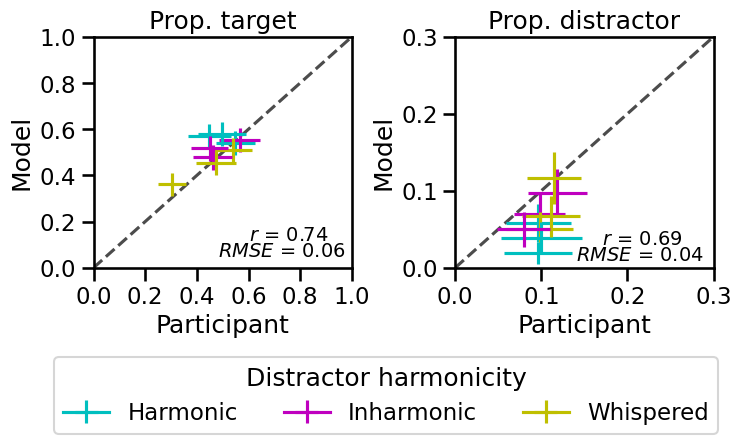

In [45]:
# plot human performance against model performance
fig, axs =  plt.subplots(1,2, figsize=(8,3))

sns.set_context('talk')
fontsize=18
# make  palette for texture labels
# palette = sns.color_palette("husl", len(harmonicity))
distractor_harms = [ 'Harmonic', 'Inharmonic', 'Whispered']
colors = [ 'c', 'm', 'y']
palette_dict = {harm:colors[ix] for ix, harm in enumerate(distractor_harms)}

harmonicity =  ['Harmonic', 'Inharmonic', 'Whispered']
markers = ['1', '+', '.']
marker_dict = {harm:markers[ix] for ix, harm in enumerate(harmonicity)}

x = y = np.linspace(0,1,5)
# plot data with 2 sem error bars
axs[0].plot(x,y, ls='dashed', color='k', alpha=0.7)
axs[1].plot(x,y, ls='dashed', color='k', alpha=0.7)

to_plot = for_scatter[for_scatter.distractor_harmonicity != "No Distractor"]
# to_plot.distractor_harmonicity = pd.CategoricalIndex(to_plot.distractor_harmonicity, categories=['No Distractor', 'Harmonic', 'Inharmonic', 'Whispered'])
# to_plot.sort_values('distractor_harmonicity', inplace=True)
# to_plot.distractor_harmonicity = to_plot.distractor_harmonicity.to_list()


for ix, row in to_plot.iterrows():
    axs[0].errorbar(x=row['participant_accuracy'],
            y=row['model_accuracy'],
            xerr = row['participant_acc_sem']*2,
            yerr=row['model_acc_sem']*2,
            label=f"{row['distractor_harmonicity']}",
            color=palette_dict[row['distractor_harmonicity']],
        #     marker=marker_dict[row['target_harmonicity']]
        )   


    axs[1].errorbar(x=row['participant_confusions'],
            y=row['model_confusions'],
            xerr = row['participant_conf_sem']*2,
            yerr=row['model_conf_sem']*2, 
            label=f"{row['distractor_harmonicity']}",
            color=palette_dict[row['distractor_harmonicity']],
        #     marker=marker_dict[row['target_harmonicity']]
        )

            # marker='o', linestyle=None, ms=3, elinewidth=2.5,)
# accs = sns.scatterplot(data=to_plot, x='participant_accuracy', y='model_accuracy',
#         hue='distractor_harmonicity', palette=palette_dict, style='target_harmonicity', ax=axs[0])


# confs = sns.scatterplot(data=to_plot, x='participant_confusions', y='model_confusions',
#         hue='distractor_harmonicity', palette=palette_dict, style='target_harmonicity', ax=axs[1],
#         )

# sns.despine()
# accs.legend().remove()


axs[0].set_xlim(0,1)
axs[0].set_ylim(0,1)

axs[0].set_xticks(np.linspace(0,1,6))
axs[0].set_yticks(np.linspace(0,1,6))

axs[1].set_xlim(0,.3)
axs[1].set_ylim(0,.3)


axs[0].set_title("Prop. target")
axs[0].set_xlabel('Participant')
axs[0].set_ylabel('Model')

axs[1].set_title("Prop. distractor")
axs[1].set_xlabel('Participant')
axs[1].set_ylabel('Model')

# Add error annotations 
# acc errors 
# res = stats.spearmanr(to_plot["participant_accuracy"].values,  to_plot['model_accuracy'].values)
# rho = res.statistic
# axs[0].annotate(f"$Rho$ = {rho:.2f}", (0.48, 0.12), fontsize=14)
r_model_human, p = stats.pearsonr(to_plot["participant_accuracy"].values,  to_plot['model_accuracy'].values)
axs[0].annotate(f"$r$ = {r_model_human:.2f}", (0.6, 0.12), fontsize=14)

samp_rmse = np.sqrt(np.mean((to_plot["participant_accuracy"].values - to_plot['model_accuracy'].values)**2))
axs[0].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.48, 0.05), fontsize=14)
# conf errors
# res = stats.spearmanr(to_plot["participant_confusions"].values,  to_plot['model_confusions'].values)
# rho = res.statistic
# axs[1].annotate(f"$Rho$ = {rho:.2f}", (0.14, 0.03), fontsize=14)   # old xy coords ( 0.25, 0.05)
r_model_human, p  = stats.pearsonr(to_plot["participant_confusions"].values,  to_plot['model_confusions'].values)
axs[1].annotate(f"$r$ = {r_model_human:.2f}", (0.17, 0.03), fontsize=14)   # old xy coords ( 0.25, 0.05)
samp_rmse = np.sqrt(np.mean((to_plot["participant_confusions"].values - to_plot['model_confusions'].values)**2))
axs[1].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.14, 0.01), fontsize=14) # old xy coords ( 0.25, 0.025)




# sns.move_legend(confs, title='', loc="center right", 
#                  bbox_to_anchor=(2.5, .5),
#                 frameon=False, )#title_size=fontsize, fontsize=fontsize)

lines_labels = [ax.get_legend_handles_labels() for ax in [axs[1]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines[:3], labels[:3],
            bbox_transform=fig.transFigure,  ncol=3, title='Distractor harmonicity',  bbox_to_anchor=(0.92, -.15),)

plt.subplots_adjust(wspace=0.4)

# plt.tight_layout()

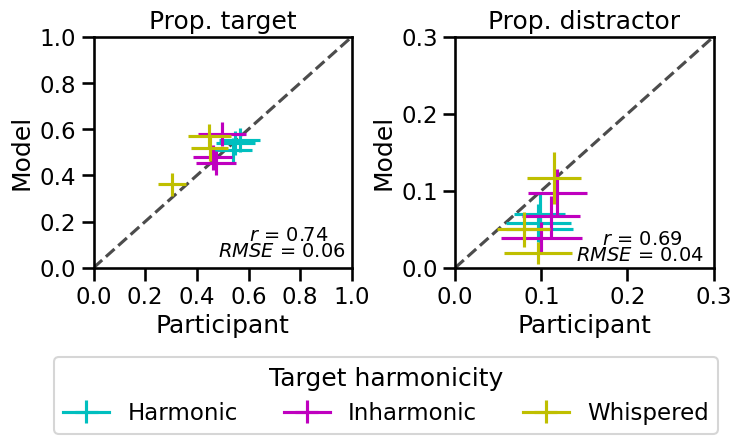

In [43]:
# plot human performance against model performance
fig, axs =  plt.subplots(1,2, figsize=(8,3))

sns.set_context('talk')
fontsize=18
# make  palette for texture labels
# palette = sns.color_palette("husl", len(harmonicity))
distractor_harms = [ 'Harmonic', 'Inharmonic', 'Whispered']
colors = [ 'c', 'm', 'y']
palette_dict = {harm:colors[ix] for ix, harm in enumerate(distractor_harms)}

harmonicity =  ['Harmonic', 'Inharmonic', 'Whispered']
markers = ['1', '+', '.']
marker_dict = {harm:markers[ix] for ix, harm in enumerate(harmonicity)}

x = y = np.linspace(0,1,5)
# plot data with 2 sem error bars
axs[0].plot(x,y, ls='dashed', color='k', alpha=0.7)
axs[1].plot(x,y, ls='dashed', color='k', alpha=0.7)

to_plot = for_scatter[for_scatter.distractor_harmonicity != "No Distractor"]
# to_plot.distractor_harmonicity = pd.CategoricalIndex(to_plot.distractor_harmonicity, categories=['No Distractor', 'Harmonic', 'Inharmonic', 'Whispered'])
# to_plot.sort_values('distractor_harmonicity', inplace=True)
# to_plot.distractor_harmonicity = to_plot.distractor_harmonicity.to_list()


for ix, row in to_plot.iterrows():
    axs[0].errorbar(x=row['participant_accuracy'],
            y=row['model_accuracy'],
            xerr = row['participant_acc_sem']*2,
            yerr=row['model_acc_sem']*2,
            label=f"{row['distractor_harmonicity']}",
            color=palette_dict[row['target_harmonicity']],
        #     marker=marker_dict[row['target_harmonicity']]
        )   


    axs[1].errorbar(x=row['participant_confusions'],
            y=row['model_confusions'],
            xerr = row['participant_conf_sem']*2,
            yerr=row['model_conf_sem']*2, 
            label=f"{row['distractor_harmonicity']}",
            color=palette_dict[row['target_harmonicity']],
        #     marker=marker_dict[row['target_harmonicity']]
        )

            # marker='o', linestyle=None, ms=3, elinewidth=2.5,)
# accs = sns.scatterplot(data=to_plot, x='participant_accuracy', y='model_accuracy',
#         hue='distractor_harmonicity', palette=palette_dict, style='target_harmonicity', ax=axs[0])


# confs = sns.scatterplot(data=to_plot, x='participant_confusions', y='model_confusions',
#         hue='distractor_harmonicity', palette=palette_dict, style='target_harmonicity', ax=axs[1],
#         )

# sns.despine()
# accs.legend().remove()


axs[0].set_xlim(0,1)
axs[0].set_ylim(0,1)

axs[0].set_xticks(np.linspace(0,1,6))
axs[0].set_yticks(np.linspace(0,1,6))

axs[1].set_xlim(0,.3)
axs[1].set_ylim(0,.3)


axs[0].set_title("Prop. target")
axs[0].set_xlabel('Participant')
axs[0].set_ylabel('Model')

axs[1].set_title("Prop. distractor")
axs[1].set_xlabel('Participant')
axs[1].set_ylabel('Model')

# Add error annotations 
# acc errors 
# res = stats.spearmanr(to_plot["participant_accuracy"].values,  to_plot['model_accuracy'].values)
# rho = res.statistic
# axs[0].annotate(f"$Rho$ = {rho:.2f}", (0.48, 0.12), fontsize=14)
r_model_human, p = stats.pearsonr(to_plot["participant_accuracy"].values,  to_plot['model_accuracy'].values)
axs[0].annotate(f"$r$ = {r_model_human:.2f}", (0.6, 0.12), fontsize=14)

samp_rmse = np.sqrt(np.mean((to_plot["participant_accuracy"].values - to_plot['model_accuracy'].values)**2))
axs[0].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.48, 0.05), fontsize=14)
# conf errors
# res = stats.spearmanr(to_plot["participant_confusions"].values,  to_plot['model_confusions'].values)
# rho = res.statistic
# axs[1].annotate(f"$Rho$ = {rho:.2f}", (0.14, 0.03), fontsize=14)   # old xy coords ( 0.25, 0.05)
r_model_human, p  = stats.pearsonr(to_plot["participant_confusions"].values,  to_plot['model_confusions'].values)
axs[1].annotate(f"$r$ = {r_model_human:.2f}", (0.17, 0.03), fontsize=14)   # old xy coords ( 0.25, 0.05)
samp_rmse = np.sqrt(np.mean((to_plot["participant_confusions"].values - to_plot['model_confusions'].values)**2))
axs[1].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.14, 0.01), fontsize=14) # old xy coords ( 0.25, 0.025)




# sns.move_legend(confs, title='', loc="center right", 
#                  bbox_to_anchor=(2.5, .5),
#                 frameon=False, )#title_size=fontsize, fontsize=fontsize)

lines_labels = [ax.get_legend_handles_labels() for ax in [axs[1]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines[::3], labels[:3],
            bbox_transform=fig.transFigure,  ncol=3, title='Target harmonicity',  bbox_to_anchor=(0.92, -.15),)

plt.subplots_adjust(wspace=0.4)

# plt.tight_layout()

In [32]:
labels

['Harmonic',
 'Inharmonic',
 'Whispered',
 'Harmonic',
 'Inharmonic',
 'Whispered',
 'Harmonic',
 'Inharmonic',
 'Whispered']

## Model-only plots

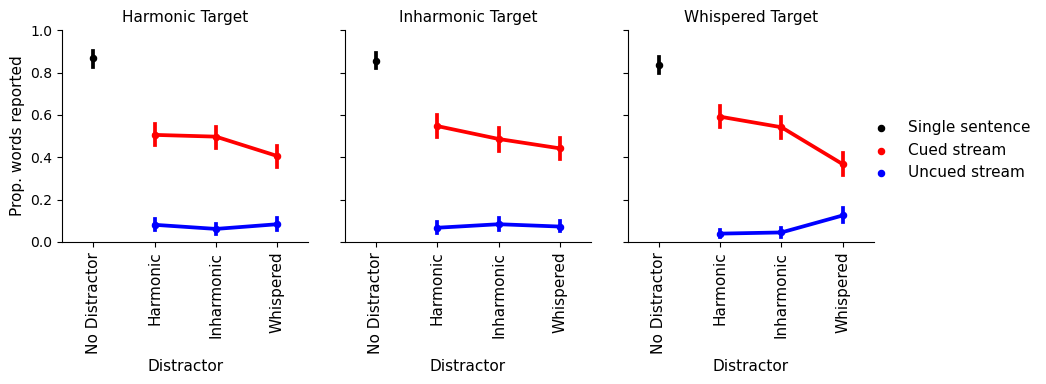

In [107]:
order = ["No Distractor", 'Harmonic', 'Inharmonic', 'Whispered']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=11


g = sns.catplot(kind='point',
    data=melted_model_results,
    col='target_harmonicity', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
    markers='.',
    x='distractor_harmonicity',
#     hue='distractor_harmonicity', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    errorbar=('ci', 95),
    height=3, aspect=1
)


g.set_axis_labels("Distractor", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=90, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

g.set_titles("{col_name} Target", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
# g.fig.suptitle('Best binaural model performance on \ninharmonic and whispered speech', size=fontsize)
# g.fig.tight_layout()


Text(0.5, 0.98, 'Model performance on \ninharmonic and whispered speech')

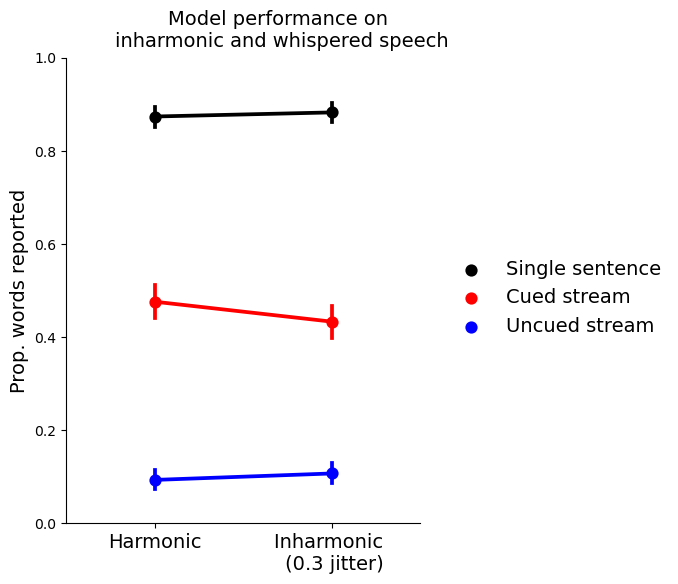

In [38]:
order = ['Harmonic', 'Inharmonic \n (0.3 jitter)']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=14


g = sns.catplot(kind='point',
    data=spch_rslts,
    x='distractor_condition', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    height=6, aspect=0.75
)


g.set_axis_labels("", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

# g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1.15, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Model performance on \ninharmonic and whispered speech', size=fontsize)
# g.fig.tight_layout()

In [167]:
melted_results.distractor_condition.unique()

array(['Harmonic', 'No Distractor', 'Inharmonic', 'Whispered'],
      dtype=object)

In [176]:
to_plot.distractor_condition.unique()

array(['Harmonic', 'Harmonic Clean', 'Whispered', 'Whispered Clean',
       'Inharmonic \n (0.3 jitter)', 'Inharmonic \n (0.3 jitter) Clean'],
      dtype=object)

In [191]:
all_results.columns

Index(['true_word_ix', 'orig_df_ix', 'model_confidence', 'accuracy',
       'pred_word_ix', 'target_condition', 'distractor_condition',
       'distractor_condition_str', 'guessed_word', 'true_word',
       'distractor_words', 'distractor_sex', 'snr', 'target_sex', 'confusion'],
      dtype='object')

## Recreate popham figure 

Text(0.5, 0.98, 'Popham-style experiment with SWC signals')

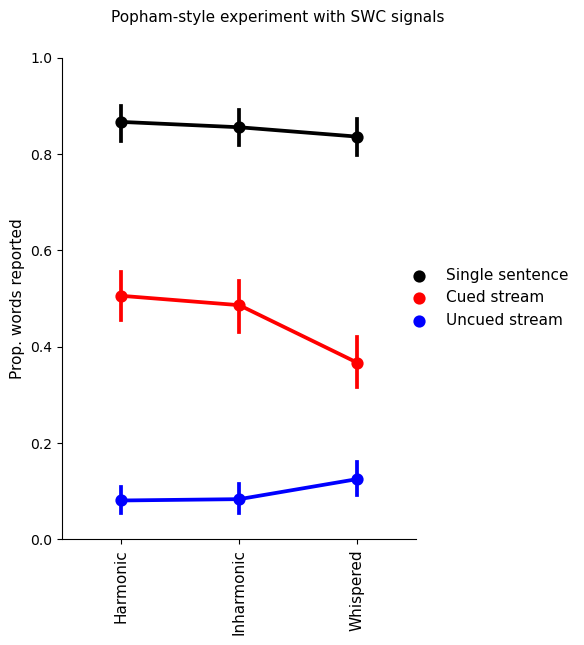

In [120]:
order = ['Harmonic', 'Inharmonic', 'Whispered']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=11

to_plot = melted_results[(melted_results.target_harmonicity == melted_results.distractor_harmonicity) | (melted_results.distractor_harmonicity == 'No Distractor')]
no_dist_IXS = to_plot[to_plot.distractor_harmonicity == 'No Distractor'].index.values
to_plot.loc[no_dist_IXS, 'distractor_harmonicity'] = to_plot.loc[no_dist_IXS, 'target_harmonicity'] 


g = sns.catplot(kind='point',
    data=to_plot,
    # col='target_harmonicity',
     y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
    # markers='.',
    x='distractor_harmonicity',
#     hue='distractor_harmonicity', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    errorbar=('ci', 95),
    height=6, aspect=.75
)


g.set_axis_labels("", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=90, size=fontsize)

g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Popham-style experiment with SWC signals', size=fontsize)
# g.fig.tight_layout()
